In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/content/country_wise_latest.csv')
display(df.head(10))

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa
5,Antigua and Barbuda,86,3,65,18,4,0,5,3.49,75.58,4.62,76,10,13.16,Americas
6,Argentina,167416,3059,72575,91782,4890,120,2057,1.83,43.35,4.21,130774,36642,28.02,Americas
7,Armenia,37390,711,26665,10014,73,6,187,1.90,71.32,2.67,34981,2409,6.89,Europe
8,Australia,15303,167,9311,5825,368,6,137,1.09,60.84,1.79,12428,2875,23.13,Western Pacific
9,Austria,20558,713,18246,1599,86,1,37,3.47,88.75,3.91,19743,815,4.13,Europe


### Data Cleaning and Preprocessing

First, let's check for missing values and review the data types of each column.

In [3]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

# Display data types
print("\nData types of each column:\n")
df.info()

Missing values in each column:
 Country/Region            0
Confirmed                 0
Deaths                    0
Recovered                 0
Active                    0
New cases                 0
New deaths                0
New recovered             0
Deaths / 100 Cases        0
Recovered / 100 Cases     0
Deaths / 100 Recovered    0
Confirmed last week       0
1 week change             0
1 week % increase         0
WHO Region                0
dtype: int64

Data types of each column:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          187 non-null    object 
 1   Confirmed               187 non-null    int64  
 2   Deaths                  187 non-null    int64  
 3   Recovered               187 non-null    int64  
 4   Active                  187 non-null    int64  
 5   New cases               1

### Exploratory Data Analysis (EDA)

In [4]:
# Display descriptive statistics for numerical columns
display(df.describe())

,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase
count,1.870000e+02,187.000000,1.870000e+02,1.870000e+02,187.000000,187.000000,187.000000,187.000000,187.000000,187.00,1.870000e+02,187.000000,187.000000
mean,8.813094e+04,3497.518717,5.063148e+04,3.400194e+04,1222.957219,28.957219,933.812834,3.019519,64.820535,inf,7.868248e+04,9448.459893,13.606203
std,3.833187e+05,14100.002482,1.901882e+05,2.133262e+05,5710.374790,120.037173,4197.719635,3.454302,26.287694,NaN,3.382737e+05,47491.127684,24.509838
min,1.000000e+01,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,1.000000e+01,-47.000000,-3.840000
25%,1.114000e+03,18.500000,6.265000e+02,1.415000e+02,4.000000,0.000000,0.000000,0.945000,48.770000,1.45,1.051500e+03,49.000000,2.775000
50%,5.059000e+03,108.000000,2.815000e+03,1.600000e+03,49.000000,1.000000,22.000000,2.150000,71.320000,3.62,5.020000e+03,432.000000,6.890000
75%,4.046050e+04,734.000000,2.260600e+04,9.149000e+03,419.500000,6.000000,221.000000,3.875000,86.885000,6.44,3.708050e+04,3172.000000,16.855000
max,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06,56336.000000,1076.000000,33728.000000,28.560000,100.000000,inf,3.834677e+06,455582.000000,226.320000


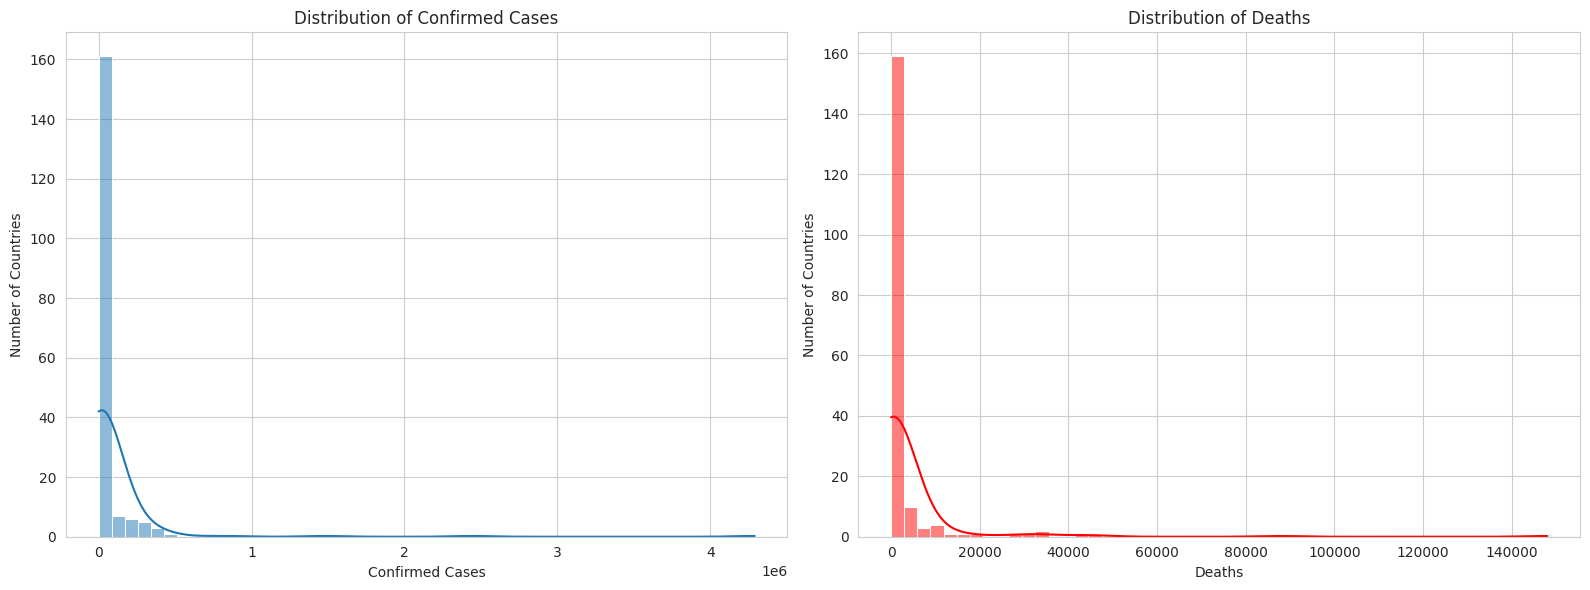

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a figure with two subplots for 'Confirmed' and 'Deaths' distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribution of Confirmed Cases
sns.histplot(df['Confirmed'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Confirmed Cases')
axes[0].set_xlabel('Confirmed Cases')
axes[0].set_ylabel('Number of Countries')

# Distribution of Deaths
sns.histplot(df['Deaths'], bins=50, kde=True, ax=axes[1], color='red')
axes[1].set_title('Distribution of Deaths')
axes[1].set_xlabel('Deaths')
axes[1].set_ylabel('Number of Countries')

plt.tight_layout()
plt.show()

The distributions of 'Confirmed Cases' and 'Deaths' are highly skewed to the right, indicating that most countries have a relatively low number of cases/deaths, while a few countries have a very high number. This is typical for such pandemic data.

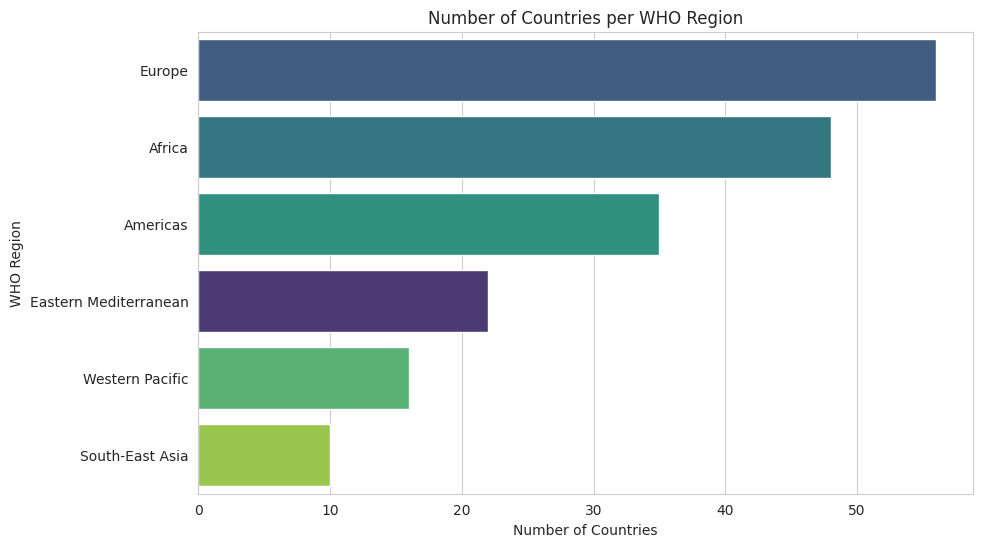

In [7]:
# Analyze the 'WHO Region' column
plt.figure(figsize=(10, 6))
sns.countplot(y='WHO Region', data=df, order=df['WHO Region'].value_counts().index, hue='WHO Region', palette='viridis', legend=False)
plt.title('Number of Countries per WHO Region')
plt.xlabel('Number of Countries')
plt.ylabel('WHO Region')
plt.show()

### Feature Engineering

Let's create some new ratio-based features to get more normalized insights and apply log transformations to highly skewed numerical columns.

In [8]:
# Create new ratio features
df['Active_Ratio'] = df['Active'] / df['Confirmed']
df['New_Cases_Ratio'] = df['New cases'] / df['Confirmed']
df['Recovery_Rate'] = df['Recovered'] / df['Confirmed']

# Handle potential division by zero which might result in NaN or Inf
df.replace([float('inf'), -float('inf')], pd.NA, inplace=True)
df['Active_Ratio'].fillna(0, inplace=True)
df['New_Cases_Ratio'].fillna(0, inplace=True)
df['Recovery_Rate'].fillna(0, inplace=True)

print("New ratio features created:")
display(df[['Active_Ratio', 'New_Cases_Ratio', 'Recovery_Rate']].head())

New ratio features created:


/tmp/ipykernel_2031/1640624026.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Active_Ratio'].fillna(0, inplace=True)
/tmp/ipykernel_2031/1640624026.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

,Active_Ratio,New_Cases_Ratio,Recovery_Rate
0,0.270138,0.002923,0.694868
1,0.407992,0.023975,0.562500
2,0.285025,0.022021,0.673399
3,0.057332,0.011025,0.885336
4,0.702105,0.018947,0.254737


In [9]:
import numpy as np

# Apply log transformation to highly skewed columns
skewed_cols = ['Confirmed', 'Deaths', 'Recovered', 'Active', 'New cases', 'New deaths', 'New recovered', 'Confirmed last week', '1 week change']

for col in skewed_cols:
    # Add a small constant (1) before log transformation to handle zero values
    df[f'log_{col}'] = np.log1p(df[col])

print("Log-transformed features created:")
display(df[[f'log_{col}' for col in skewed_cols]].head())

Log-transformed features created:


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


,log_Confirmed,log_Deaths,log_Recovered,log_Active,log_New cases,log_New deaths,log_New recovered,log_Confirmed last week,log_1 week change
0,10.498581,7.146772,10.134560,9.189831,4.672829,2.397895,2.944439,10.478048,6.603944
1,8.493105,4.976734,7.917901,7.596894,4.770685,1.945910,4.158883,8.336151,6.565265
2,10.239031,7.059618,9.843631,8.983942,6.424869,2.197225,6.620073,10.072893,8.362409
3,6.811244,3.970292,6.689599,3.970292,2.397895,0.000000,0.000000,6.785588,3.178054
4,6.857514,3.737670,5.493061,6.504288,2.944439,0.693147,0.000000,6.620073,5.308268


### Feature Selection

Now that we've engineered some new features, let's look into potential feature selection by examining correlations between features. This can help identify redundant features or those that might not contribute much to a potential model.

### Data Preparation for Machine Learning

Now that we have a target variable ('log_Confirmed' cases), let's prepare our dataset for a regression task. This involves separating the features (X) from the target (y) and then splitting the data into training and testing sets.

In [14]:
from sklearn.model_selection import train_test_split
import numpy as np

# Define target variable (y) and features (X)
# We will use the log-transformed 'Confirmed' as our target due to its skewed nature
y = df['log_Confirmed']

# For features, we'll drop the original 'Confirmed' column and its log-transformed version,
# along with other highly correlated or non-predictive columns.
# We also drop non-numeric and ratio features that might lead to data leakage or multicollinearity issues initially.
# 'WHO Region' is categorical and would need one-hot encoding, which we'll skip for now for simplicity.

# Identify columns to drop from features
columns_to_drop = [
    'Country/Region', 'Confirmed', 'log_Confirmed',
    'Deaths', 'log_Deaths', 'Recovered', 'log_Recovered',
    'Active', 'log_Active', 'New cases', 'log_New cases',
    'New deaths', 'log_New deaths', 'New recovered', 'log_New recovered',
    'Confirmed last week', 'log_Confirmed last week', '1 week change', 'log_1 week change',
    'WHO Region', 'Active_Ratio', 'New_Cases_Ratio', 'Recovery_Rate'
]

# Filter out columns that are not present in df to avoid errors
columns_to_drop = [col for col in columns_to_drop if col in df.columns]

X = df.drop(columns=columns_to_drop)

# Keep only numerical features that are not directly correlated with the target or are not ratios derived from it
# We will select some features based on our initial EDA and correlation analysis, avoiding highly correlated pairs.
# For a first pass, let's include some key indicators that are not direct calculations of 'Confirmed'.
X = X[['Deaths / 100 Cases', 'Recovered / 100 Cases', 'Deaths / 100 Recovered', '1 week % increase']]

# Convert pd.NA to np.nan and then fill np.nan with 0 to ensure all features are numerical floats
X = X.replace(pd.NA, np.nan).fillna(0)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

display(X_train.head())


Shape of X_train: (149, 4)
Shape of X_test: (38, 4)
Shape of y_train: (149,)
Shape of y_test: (38,)


/tmp/ipykernel_2031/1254005631.py:34: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = X.replace(pd.NA, np.nan).fillna(0)


,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,1 week % increase
95,2.54,85.73,2.97,2.27
69,0.00,100.00,0.00,0.00
109,2.51,74.95,3.35,4.81
29,0.95,66.58,1.42,12.41
126,2.79,95.84,2.91,1.08


### Model Training and Evaluation

Let's train a Random Forest Regressor model to predict the `log_Confirmed` cases and evaluate its performance.

In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize the Random Forest Regressor model
# Using a random_state for reproducibility
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")

# To get a sense of the actual 'Confirmed' cases, we can inverse transform:
# First, inverse transform the predicted log values
y_pred_original_scale = np.expm1(y_pred)
y_test_original_scale = np.expm1(y_test)

mse_original_scale = mean_squared_error(y_test_original_scale, y_pred_original_scale)
r2_original_scale = r2_score(y_test_original_scale, y_pred_original_scale)

print(f"\nMean Squared Error (Original Scale): {mse_original_scale:.2f}")
print(f"R-squared (Original Scale): {r2_original_scale:.4f}")


Mean Squared Error (MSE): 6.5305
R-squared (R2) Score: 0.2832

Mean Squared Error (Original Scale): 33853724191.22
R-squared (Original Scale): -0.2692


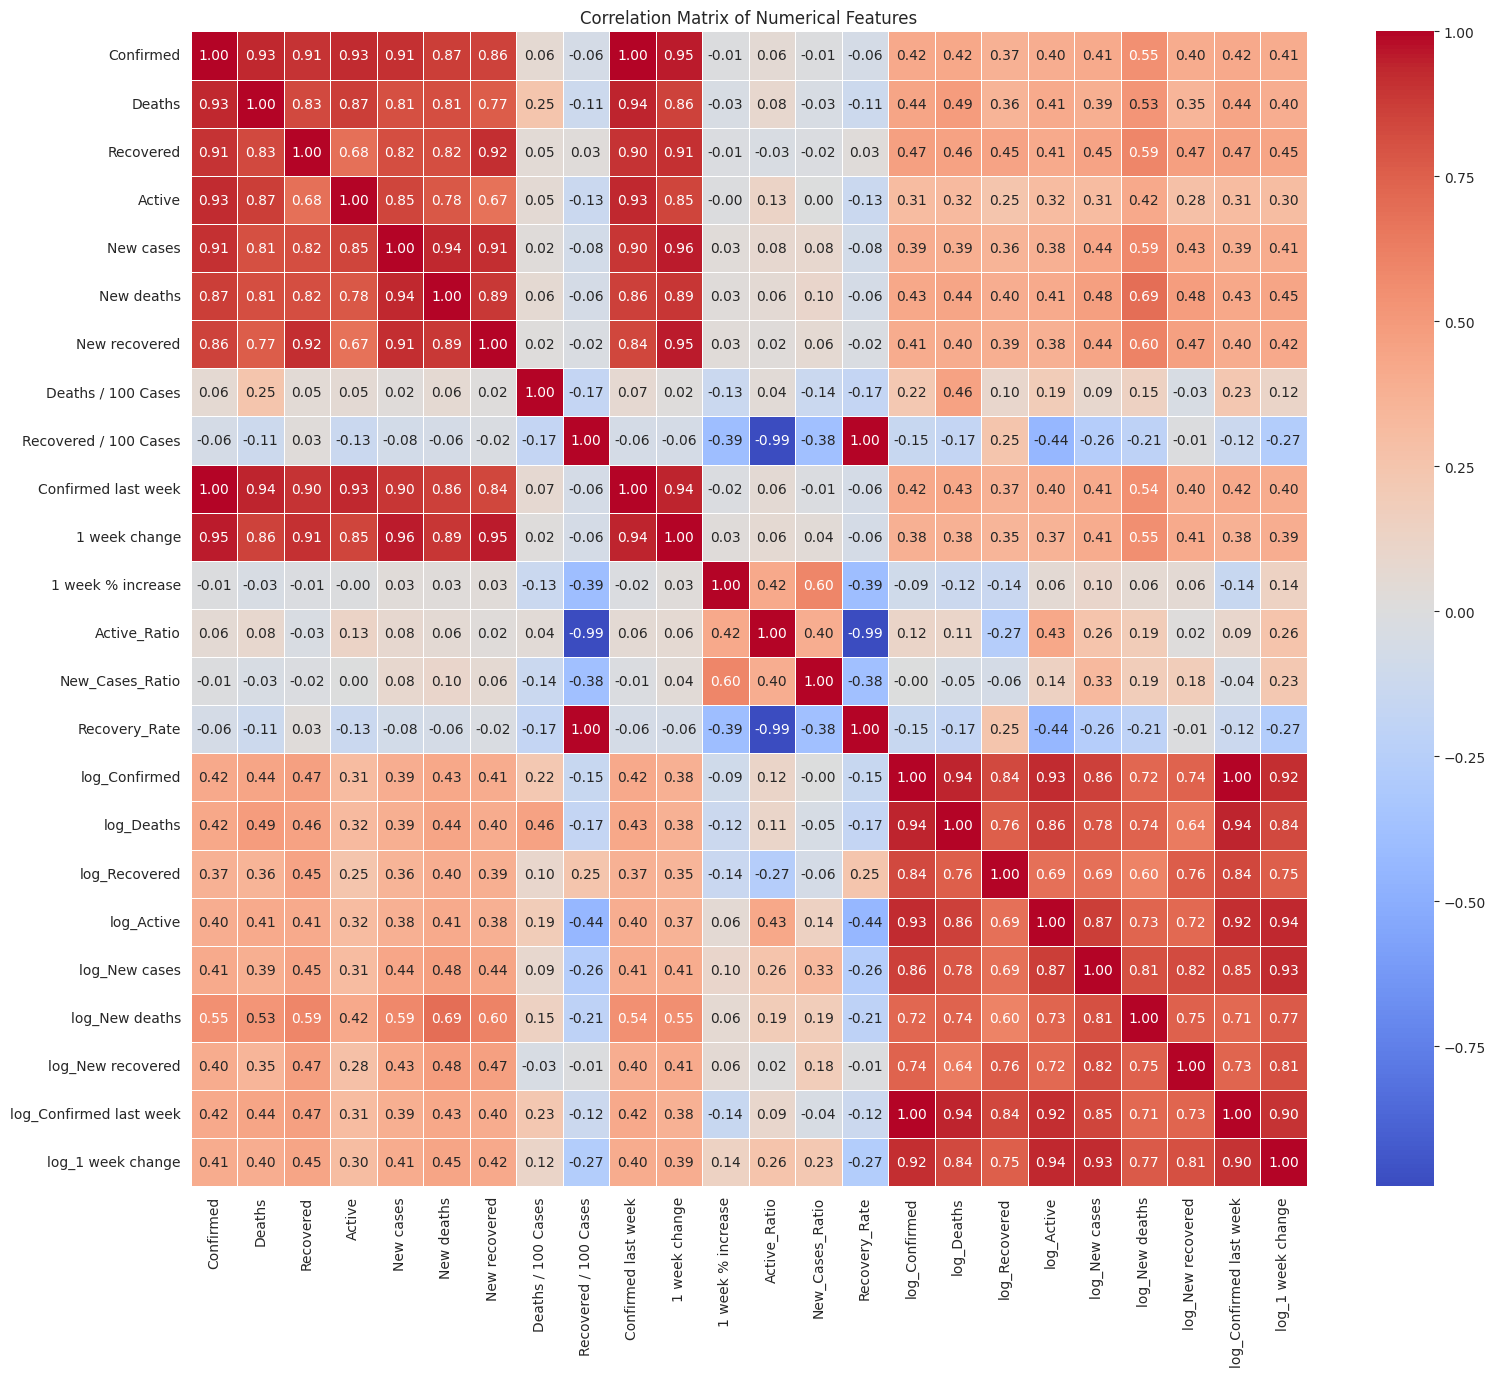

Correlation matrix of numerical features displayed above. High correlations might indicate redundancy.


In [10]:
# Calculate the correlation matrix for numerical features
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
correlation_matrix = df[numerical_cols].corr()

# Plotting the heatmap
plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

print("Correlation matrix of numerical features displayed above. High correlations might indicate redundancy.")

### Refined Feature Selection and Engineering

To improve our model, we will refine our feature selection by including the categorical 'WHO Region' through one-hot encoding and selecting a more robust set of numerical features based on correlation analysis.

In [16]:
# One-hot encode the 'WHO Region' categorical feature
df_encoded = pd.get_dummies(df, columns=['WHO Region'], drop_first=True, dtype=int)

print("DataFrame after one-hot encoding 'WHO Region':")
display(df_encoded.head())

DataFrame after one-hot encoding 'WHO Region':


,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,...,log_New cases,log_New deaths,log_New recovered,log_Confirmed last week,log_1 week change,WHO Region_Americas,WHO Region_Eastern Mediterranean,WHO Region_Europe,WHO Region_South-East Asia,WHO Region_Western Pacific
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,...,4.672829,2.397895,2.944439,10.478048,6.603944,0,1,0,0,0
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,...,4.770685,1.945910,4.158883,8.336151,6.565265,0,0,1,0,0
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,...,6.424869,2.197225,6.620073,10.072893,8.362409,0,0,0,0,0
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,...,2.397895,0.000000,0.000000,6.785588,3.178054,0,0,1,0,0
4,Angola,950,41,242,667,18,1,0,4.32,25.47,...,2.944439,0.693147,0.000000,6.620073,5.308268,0,0,0,0,0


In [17]:
# Define target variable (y)
y = df_encoded['log_Confirmed']

# Select a new set of features for X, including some log-transformed values and one-hot encoded regions
# We avoid features that are directly derived from Confirmed cases or are too highly correlated with each other
# to prevent data leakage and multicollinearity.

selected_features = [
    'log_Deaths',
    'log_Active',
    'log_1 week change',
    '1 week % increase',
    'Deaths / 100 Cases',
    'Recovered / 100 Cases',
    'Deaths / 100 Recovered'
]

# Add one-hot encoded WHO Region columns
who_region_cols = [col for col in df_encoded.columns if 'WHO Region_' in col]
selected_features.extend(who_region_cols)

X = df_encoded[selected_features]

# Convert pd.NA to np.nan and then fill np.nan with 0 to ensure all features are numerical floats
X = X.replace(pd.NA, np.nan).fillna(0)

print(f"Selected features for X: {selected_features}")
display(X.head())

Selected features for X: ['log_Deaths', 'log_Active', 'log_1 week change', '1 week % increase', 'Deaths / 100 Cases', 'Recovered / 100 Cases', 'Deaths / 100 Recovered', 'WHO Region_Americas', 'WHO Region_Eastern Mediterranean', 'WHO Region_Europe', 'WHO Region_South-East Asia', 'WHO Region_Western Pacific']


/tmp/ipykernel_2031/2584386725.py:25: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = X.replace(pd.NA, np.nan).fillna(0)


,log_Deaths,log_Active,log_1 week change,1 week % increase,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,WHO Region_Americas,WHO Region_Eastern Mediterranean,WHO Region_Europe,WHO Region_South-East Asia,WHO Region_Western Pacific
0,7.146772,9.189831,6.603944,2.07,3.50,69.49,5.04,0,1,0,0,0
1,4.976734,7.596894,6.565265,17.00,2.95,56.25,5.25,0,0,1,0,0
2,7.059618,8.983942,8.362409,18.07,4.16,67.34,6.17,0,0,0,0,0
3,3.970292,3.970292,3.178054,2.60,5.73,88.53,6.48,0,0,1,0,0
4,3.737670,6.504288,5.308268,26.84,4.32,25.47,16.94,0,0,0,0,0


In [18]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets with the new feature set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train (new feature set): {X_train.shape}")
print(f"Shape of X_test (new feature set): {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train (new feature set): (149, 12)
Shape of X_test (new feature set): (38, 12)
Shape of y_train: (149,)
Shape of y_test: (38,)


### Re-training and Re-evaluating Model

Now, let's re-train the Random Forest Regressor with the refined feature set and evaluate its performance to see if there's an improvement.

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize the Random Forest Regressor model again
model_refined = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model with the new training data
model_refined.fit(X_train, y_train)

# Make predictions on the test set
y_pred_refined = model_refined.predict(X_test)

# Evaluate the model
mse_refined = mean_squared_error(y_test, y_pred_refined)
r2_refined = r2_score(y_test, y_pred_refined)

print(f"Mean Squared Error (MSE) with refined features: {mse_refined:.4f}")
print(f"R-squared (R2) Score with refined features: {r2_refined:.4f}")

# Inverse transform to original scale for better interpretation
y_pred_original_scale_refined = np.expm1(y_pred_refined)
y_test_original_scale = np.expm1(y_test)

mse_original_scale_refined = mean_squared_error(y_test_original_scale, y_pred_original_scale_refined)
r2_original_scale_refined = r2_score(y_test_original_scale, y_pred_original_scale_refined)

print(f"\nMean Squared Error (Original Scale) with refined features: {mse_original_scale_refined:.2f}")
print(f"R-squared (Original Scale) with refined features: {r2_original_scale_refined:.4f}")

Mean Squared Error (MSE) with refined features: 0.2579
R-squared (R2) Score with refined features: 0.9717

Mean Squared Error (Original Scale) with refined features: 9825745375.79
R-squared (Original Scale) with refined features: 0.6316


### Saving the Model

Let's save the trained `model_refined` using `pickle` so it can be reloaded and used later without needing to retrain.

In [20]:
import pickle

# Save the refined model to a .pkl file
filename = 'model.pkl'
pickle.dump(model_refined, open(filename, 'wb'))

print(f"Model successfully saved as '{filename}'")

Model successfully saved as 'model.pkl'


This count plot shows the number of countries belonging to each WHO Region, helping us understand the regional representation in our dataset.